# Quantitative Modeling of AI Inference Energy Consumption

This notebook implements the simulation described in Chapter 4 of the thesis.

**Block 0**: System variables and constants. Set `arrival_mode` (`nhpp_only` or `hybrid`) and `strategy_mode` (`Static`, `Conservative`, `Aggressive`) here.

**Block 1**: Arrival process. Generates the NHPP base and the Pareto burst overlay, then writes whichever one is selected into `lambda_15min`.

**Block 2**: Capacity, utilisation, and cold-start lag. Reports SLA violations.

**Block 3**: Three-state GPU distribution.

**Block 4**: Energy accounting (kWh per state, daily totals).

**Block 5**: Strategy x arrival-process comparison table (matches Table 4.2 in the thesis).

**Block 6**: Headroom sweep — SLA violations versus provisioning overhead (25% → 0%).


In [1]:
# --- Block 0: System Variables & Constants ---
import sys
from pathlib import Path

import numpy as np
import matplotlib.pyplot as plt

# Make src/ importable when the notebook is launched from notebooks/
_REPO_ROOT = Path("..").resolve()
if str(_REPO_ROOT) not in sys.path:
    sys.path.insert(0, str(_REPO_ROOT))

from src.config import (
    ARRIVAL_MODES,
    BURST_DISTRIBUTIONS,
    ArrivalParams,
    BurstParams,
    ClusterParams,
    DIURNAL_SHAPE,
    PowerParams,
    STRATEGIES,
)

FIG_DIR = Path("../figures")
FIG_DIR.mkdir(parents=True, exist_ok=True)

# Reproducibility: fix the RNG seed so every run produces identical numbers
np.random.seed(67)

# @title Simulation Configuration
# All numeric constants live in src/config.py. Edit them there (or pass
# overrides to the dataclass constructors below) to change the simulation.
cluster        = ClusterParams()
power          = PowerParams()
arrival_params = ArrivalParams()  # used when arrival_mode == 'gamma_renewal'

# --- Runtime toggles (Colab-style dropdowns) ---
arrival_mode       = 'hybrid'        # @param ["nhpp_only", "hybrid", "gamma_renewal"]
burst_distribution = 'pareto'        # @param ["pareto", "gamma"]   (only used when arrival_mode == "hybrid")
strategy_mode      = 'Conservative'  # @param ["Static", "Conservative", "Moderate", "Tight", "Aggressive"]
burst_params = BurstParams(distribution=burst_distribution)

# --- Derived queueing-model label ---
# Service times are exponential (M) and we have c=total_gpus parallel servers.
# The arrival process determines the first letter:
#   nhpp_only      -> Poisson  -> M/M/c
#   hybrid         -> Poisson base + bursts (batch) -> M^[X]/M/c (informal)
#   gamma_renewal  -> Gamma renewal -> G/M/c
if arrival_mode == 'nhpp_only':
    queueing_model = 'M/M/c'
elif arrival_mode == 'hybrid':
    queueing_model = f'M/M/c + {burst_distribution.capitalize()} burst overlay'
elif arrival_mode == 'gamma_renewal':
    queueing_model = 'G/M/c'
else:
    queueing_model = '?'

# --- Local aliases consumed by Blocks 1-7 ---
mu          = cluster.mu
total_gpus  = cluster.total_gpus
pod_size    = cluster.pod_size
c_peak      = cluster.c_peak
T_day       = cluster.T_day_hours
step_hours  = cluster.step_hours
num_steps   = cluster.num_steps
lambda_peak = cluster.lambda_peak       # = target_rho_conservative * mu * c_peak

P_idle           = power.p_idle
P_execution_idle = power.p_execution_idle
P_active_avg     = power.p_active_avg
EXEC_IDLE_FRAC   = power.execution_idle_fraction

# Workload time axis
lambda_hourly     = DIURNAL_SHAPE * lambda_peak  # req/s, 24 hourly values
hours_24          = np.arange(int(T_day))
hours_96          = np.arange(0, T_day, step_hours)  # name kept for back-compat
lambda_15min_nhpp = np.interp(hours_96, hours_24, lambda_hourly)
max_lam           = lambda_15min_nhpp.max()
lambda_15min      = lambda_15min_nhpp.copy()

# Pod-quantised provisioning helper
def scale_in_pods(c_target):
    return np.ceil(c_target / pod_size) * pod_size

# Provisioning arrays for the chosen strategy (Block 1 may overwrite if arrival_mode != 'nhpp_only')
c_static       = np.full(num_steps, total_gpus)
c_conservative = np.minimum(scale_in_pods(lambda_15min / (cluster.target_rho_conservative * mu)), total_gpus)
c_moderate     = np.minimum(scale_in_pods(lambda_15min / (cluster.target_rho_moderate     * mu)), total_gpus)
c_tight        = np.minimum(scale_in_pods(lambda_15min / (cluster.target_rho_tight        * mu)), total_gpus)
c_aggressive   = np.minimum(scale_in_pods(lambda_15min / (cluster.target_rho_aggressive   * mu)), total_gpus)

if strategy_mode == "Static":
    c_active = c_static
elif strategy_mode == "Conservative":
    c_active = c_conservative
elif strategy_mode == "Moderate":
    c_active = c_moderate
elif strategy_mode == "Tight":
    c_active = c_tight
elif strategy_mode == "Aggressive":
    c_active = c_aggressive

print(f"Block 0 initialised ({cluster.step_minutes:.0f}-minute resolution, "
      f"{num_steps} steps over {T_day:.0f} h).")
print(f"  Arrival mode:    {arrival_mode}")
print(f"  Queue model:     {queueing_model}")
if arrival_mode == 'hybrid':
    print(f"  Burst dist:      {burst_distribution}")
elif arrival_mode == 'gamma_renewal':
    print(f"  Renewal shape:   {arrival_params.gamma_renewal_shape} "
          f"(CV ~= {1/np.sqrt(arrival_params.gamma_renewal_shape):.2f})")
print(f"  Strategy:        {strategy_mode}")
print(f"  Cluster size:    {total_gpus} GPUs (pod_size={pod_size})")
print(f"  mu:              {mu} req/s")
print(f"  lambda_peak:     {lambda_peak:.1f} req/s "
      f"(c_peak={c_peak} GPUs at rho={cluster.target_rho_conservative:.2f})")
print(f"  lambda_mean:     {lambda_hourly.mean():.1f} req/s")


Block 0 initialised (3-minute resolution, 480 steps over 24 h).
  Arrival mode:    hybrid
  Queue model:     M/M/c + Pareto burst overlay
  Burst dist:      pareto
  Strategy:        Conservative
  Cluster size:    256 GPUs (pod_size=8)
  mu:              0.2 req/s
  lambda_peak:     31.2 req/s (c_peak=200 GPUs at rho=0.78)
  lambda_mean:     16.9 req/s


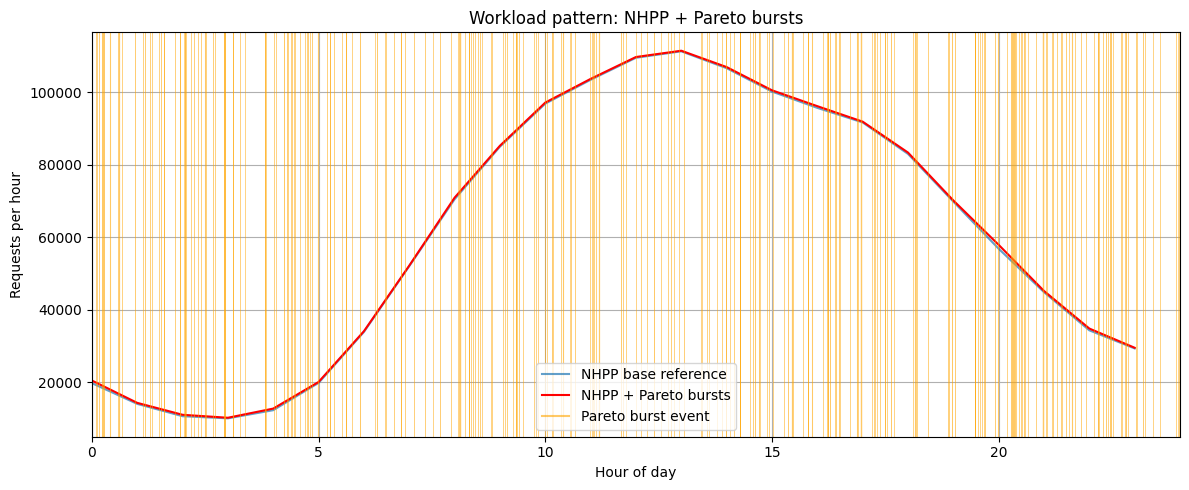

NHPP arrivals (reference): 1460546
Active arrivals:           1468876  (NHPP + Pareto bursts)
Burst events:              252
Largest burst:             739 requests
Active lambda(t):
  max:  31.49 req/s
  mean: 17.00 req/s


In [2]:
# --- Block 1: Arrival Rate / Workload ---
import numpy as np
import matplotlib.pyplot as plt

from src.Simulation import (
    bin_to_15min_rate,
    simulate_bursts,
    simulate_gamma_renewal_nhpp,
    simulate_nhpp,
)


def daily_intensity(t):
    # Linear interpolation between hourly anchors so the NHPP thinning
    # sees a continuous lambda(t) instead of a stair-step.
    return float(np.interp(t % 24, np.arange(24), lambda_hourly))


# Always compute a pure NHPP base for the comparison plot (no toggle effect).
base_arrivals = simulate_nhpp(daily_intensity, max_lam, T_day)

# Build the active arrival sequence for the selected mode.
burst_times: list[float] = []
burst_sizes: list[int]   = []

if arrival_mode == 'nhpp_only':
    active_arrivals = list(base_arrivals)
    overlay_label   = 'NHPP only'

elif arrival_mode == 'hybrid':
    burst_arrivals, burst_times, burst_sizes = simulate_bursts(
        burst_params, T=T_day, lambda_peak=lambda_peak,
    )
    active_arrivals = sorted(base_arrivals + burst_arrivals)
    overlay_label   = f'NHPP + {burst_params.distribution.capitalize()} bursts'

elif arrival_mode == 'gamma_renewal':
    active_arrivals = simulate_gamma_renewal_nhpp(
        arrival_params.gamma_renewal_shape,
        arrival_params.gamma_renewal_scale,
        daily_intensity, T_day,
    )
    overlay_label = (
        f'Gamma renewal (shape={arrival_params.gamma_renewal_shape}, '
        f'CV~={1/np.sqrt(arrival_params.gamma_renewal_shape):.2f}) - BurstGPT'
    )

else:
    raise ValueError(f"Unknown arrival_mode {arrival_mode!r}")

# Build lambda(t) at the configured resolution for the active mode
lambda_15min_active = bin_to_15min_rate(
    active_arrivals, num_steps=num_steps, step_hours=step_hours,
)
# Keep the legacy name for downstream cells (compare-all uses both lambda_15min_nhpp
# and lambda_15min_active via build_lambda_15min, so this drift is fine).
lambda_15min_hybrid = lambda_15min_active

if arrival_mode == 'nhpp_only':
    lambda_15min = lambda_15min_nhpp.copy()
else:
    lambda_15min = lambda_15min_active
    c_conservative = np.minimum(scale_in_pods(lambda_15min / (cluster.target_rho_conservative * mu)), total_gpus)
    c_moderate     = np.minimum(scale_in_pods(lambda_15min / (cluster.target_rho_moderate     * mu)), total_gpus)
    c_tight        = np.minimum(scale_in_pods(lambda_15min / (cluster.target_rho_tight        * mu)), total_gpus)
    c_aggressive   = np.minimum(scale_in_pods(lambda_15min / (cluster.target_rho_aggressive   * mu)), total_gpus)
    if strategy_mode == "Conservative":
        c_active = c_conservative
    elif strategy_mode == "Moderate":
        c_active = c_moderate
    elif strategy_mode == "Tight":
        c_active = c_tight
    elif strategy_mode == "Aggressive":
        c_active = c_aggressive
    elif strategy_mode == "Static":
        c_active = c_static

# --- Visualisation: hourly request counts ---
hours = np.arange(24)
requests_nhpp   = [len([t for t in base_arrivals    if h <= t < h + 1]) for h in hours]
requests_active = [len([t for t in active_arrivals  if h <= t < h + 1]) for h in hours]

fig, ax = plt.subplots(figsize=(12, 5))
ax.plot(hours, requests_nhpp,   label='NHPP base reference', alpha=0.7)
ax.plot(hours, requests_active, label=overlay_label,
        color='red', linewidth=1.5)

# In hybrid mode, mark each burst event
if arrival_mode == 'hybrid' and burst_sizes:
    for bt, bs in zip(burst_times, burst_sizes):
        ax.axvline(x=bt, color='orange', alpha=0.6,
                   linewidth=0.5 + (bs / max(burst_sizes)) * 3)
    ax.axvline(x=-1, color='orange', alpha=0.6, linewidth=1.5,
               label=f'{burst_params.distribution.capitalize()} burst event')

ax.set_title(f'Workload pattern: {overlay_label}')
ax.set_xlabel('Hour of day')
ax.set_ylabel('Requests per hour')
ax.set_xlim(0, 24)
ax.legend()
ax.grid(True)
plt.tight_layout()
fig.savefig(FIG_DIR / "workload_pattern.png", dpi=300, bbox_inches="tight")
plt.show()
plt.close()

print(f"NHPP arrivals (reference): {len(base_arrivals)}")
print(f"Active arrivals:           {len(active_arrivals)}  ({overlay_label})")
if arrival_mode == 'hybrid':
    print(f"Burst events:              {len(burst_times)}")
    if burst_sizes:
        print(f"Largest burst:             {max(burst_sizes):,} requests")
print(f"Active lambda(t):")
print(f"  max:  {lambda_15min.max():.2f} req/s")
print(f"  mean: {lambda_15min.mean():.2f} req/s")


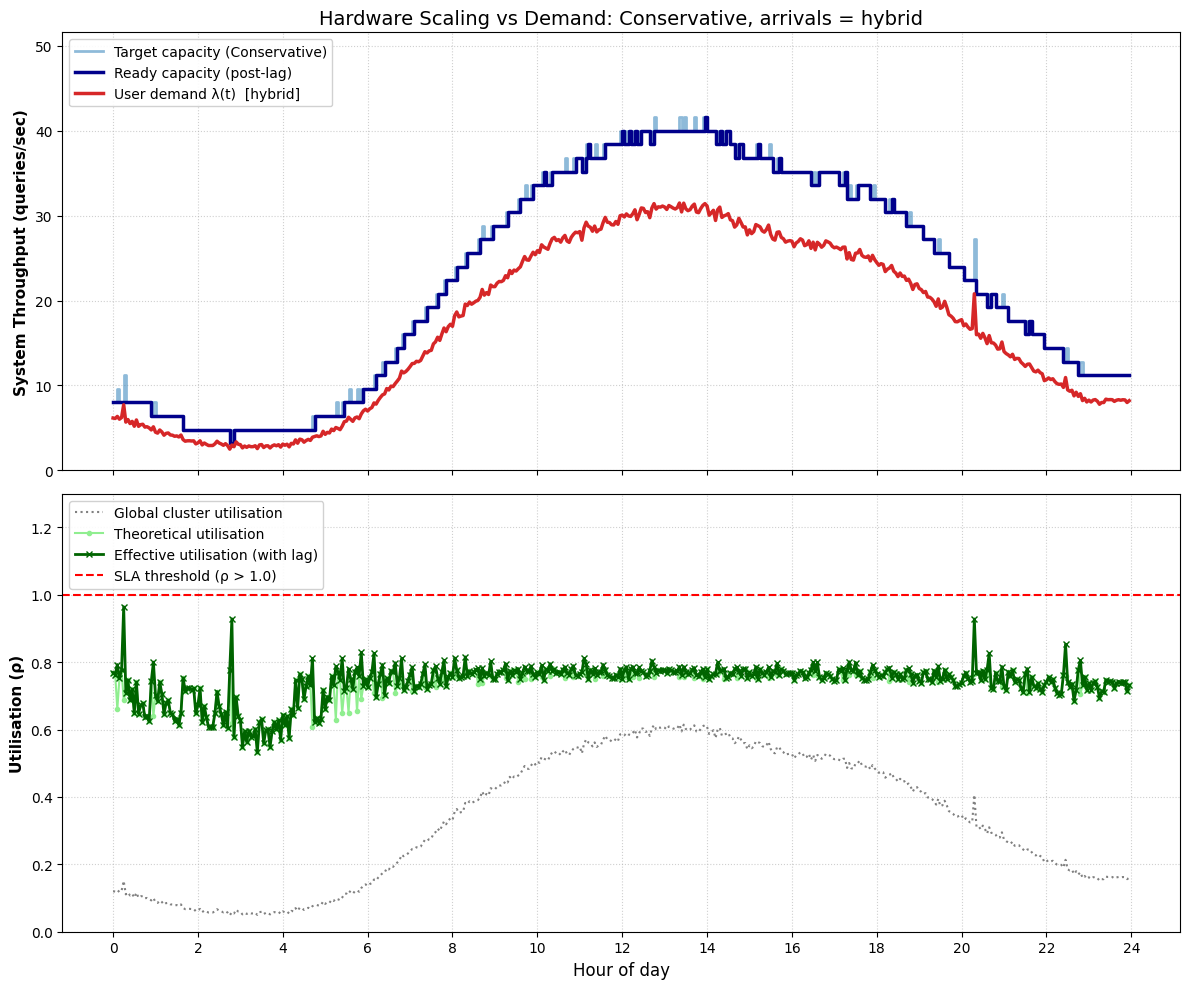


--- Strategy Results: Conservative, arrivals = hybrid ---
Mean effective utilisation: 0.742
Max  effective utilisation: 0.965
System stable: headroom absorbed the cold-start lag and any bursts.


In [3]:
# --- Block 2: Capacity, Utilisation, and Cold-Start Lag ---
import numpy as np
import matplotlib.pyplot as plt

# 1. Real-world hardware lag (exactly 1 time step for a scale-up).
#    Scale-down is treated as instantaneous.
c_ready = np.zeros(num_steps)
c_ready[0] = c_active[0]
for t in range(1, num_steps):
    # If scaling UP:    min keeps c_ready at the previous (lower) state for 1 step
    # If scaling DOWN:  min instantly adopts the new (lower) state
    c_ready[t] = np.minimum(c_active[t], c_active[t-1])

# 2. Convert servers to throughput (queries per second)
capacity_target_qps = c_active * mu
capacity_ready_qps  = c_ready  * mu
demand_qps          = lambda_15min

# 3. Utilisation calculations (safe against capacity_ready_qps == 0)
rho_theoretical = np.where(capacity_target_qps > 0,
                           lambda_15min / np.maximum(capacity_target_qps, 1e-9), 0.0)
rho_effective   = np.where(capacity_ready_qps  > 0,
                           lambda_15min / np.maximum(capacity_ready_qps,  1e-9), 0.0)
global_rho_t    = lambda_15min / (total_gpus * mu)

# 4. Visualisation: two-panel chart
fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(12, 10), sharex=True)

ax1.set_ylabel('System Throughput (queries/sec)', fontsize=11, fontweight='bold')
ax1.step(hours_96, capacity_target_qps, where='post', color='tab:blue', linewidth=2, alpha=0.5,
         label=f'Target capacity ({strategy_mode})')
ax1.step(hours_96, capacity_ready_qps, where='post', color='darkblue', linewidth=2.5,
         label='Ready capacity (post-lag)')
ax1.plot(hours_96, demand_qps, color='tab:red', linestyle='-', linewidth=2.5,
         label=f'User demand \u03BB(t)  [{arrival_mode}]')
ax1.set_ylim(0, max(capacity_target_qps.max(), demand_qps.max()) + 10)
ax1.set_title(f'Hardware Scaling vs Demand: {strategy_mode}, arrivals = {arrival_mode}', fontsize=14)
ax1.legend(loc='upper left', framealpha=0.9)
ax1.grid(True, linestyle=':', alpha=0.6)

ax2.set_xlabel('Hour of day', fontsize=12)
ax2.set_ylabel('Utilisation (\u03C1)', fontsize=11, fontweight='bold')
ax2.plot(hours_96, global_rho_t,    color='grey',       linestyle=':',  linewidth=1.5,
         label='Global cluster utilisation')
ax2.plot(hours_96, rho_theoretical, color='lightgreen', marker='.',
         linestyle='-',  linewidth=1.5, label='Theoretical utilisation')
ax2.plot(hours_96, rho_effective,   color='darkgreen',  marker='x', markersize=4,
         linestyle='-',  linewidth=2,   label='Effective utilisation (with lag)')
ax2.axhline(y=1.0, color='red', linestyle='--', linewidth=1.5,
            label='SLA threshold (\u03C1 > 1.0)')
ax2.set_ylim(0, max(1.3, rho_effective.max() * 1.05))
ax2.set_xticks(np.arange(0, 25, 2))
ax2.legend(loc='upper left', framealpha=0.9)
ax2.grid(True, linestyle=':', alpha=0.6)

plt.tight_layout()
fig.savefig(FIG_DIR / "capacity_utilisation_cold_start.png", dpi=300, bbox_inches="tight")
plt.show()
plt.close()

# --- SLA violation check ---
print(f"\n--- Strategy Results: {strategy_mode}, arrivals = {arrival_mode} ---")
overloaded_steps = np.where(rho_effective > 1)[0]
print(f"Mean effective utilisation: {np.mean(rho_effective):.3f}")
print(f"Max  effective utilisation: {np.max(rho_effective):.3f}")
if len(overloaded_steps) == 0:
    print("System stable: headroom absorbed the cold-start lag and any bursts.")
else:
    print(f"SLA violations detected in {len(overloaded_steps)} of {num_steps} intervals.")


```markdown
# Block 3: GPU States.  GPU states introduces latency ->
When utilized: x "active inference state" and 1-x "execution idle"
When not utilization, assume execution idle.
Once you have ratios of everything, we can use that for next step. Graph the ratios on a column graph. Proportional colors of each state.

```

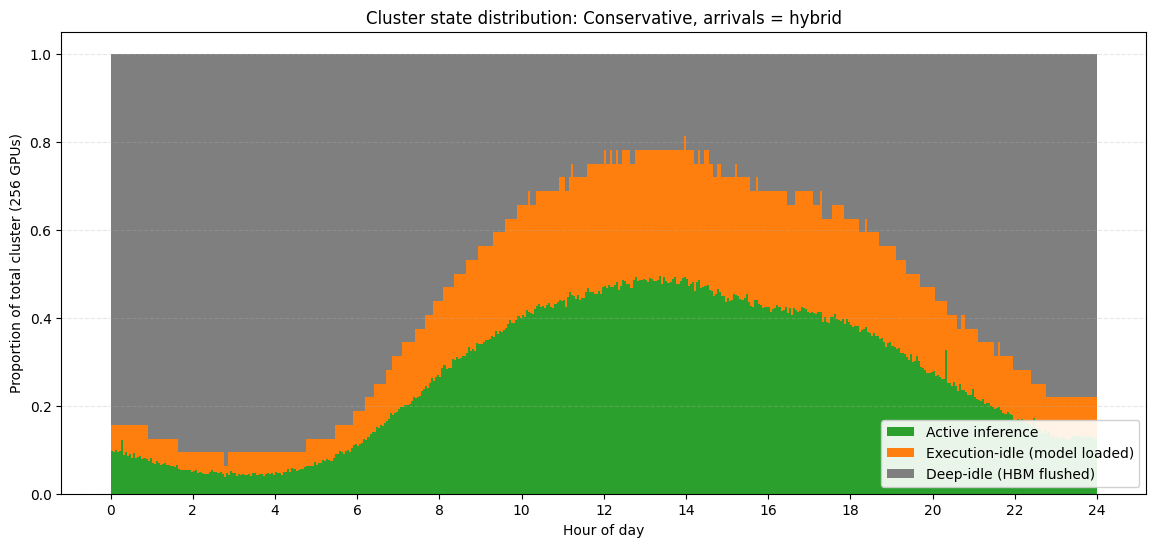

--- Daily state averages: Conservative, hybrid ---
  Active inference:   26.7%
  Execution-idle:     17.0%
  Deep-idle:          56.3%


In [4]:
# --- Block 3: GPU State Distribution ---
import numpy as np
import matplotlib.pyplot as plt

# When rho_effective > 1 (SLA violation), the cluster is over capacity.
# For the state breakdown we cap at 1.0 (the cluster cannot have a fractional
# active count above its size). The SLA violation is reported separately
# in Block 2.
rho_state = np.minimum(rho_effective, 1.0)

# 1. Physical number of GPUs in each state per simulation step
gpus_active     = c_ready * rho_state * (1 - EXEC_IDLE_FRAC)
gpus_exec_idle  = c_ready * ((rho_state * EXEC_IDLE_FRAC) + (1 - rho_state))
gpus_deep_idle  = total_gpus - c_ready

# 2. Cluster proportions (0.0 to 1.0)
active_ratio          = gpus_active    / total_gpus
execution_idle_ratio  = gpus_exec_idle / total_gpus
deep_idle_ratio       = gpus_deep_idle / total_gpus

# 3. Stacked bar chart (per step)
plt.figure(figsize=(14, 6))
plt.bar(hours_96, active_ratio, width=step_hours, label='Active inference',
        color='#2ca02c', align='edge')
plt.bar(hours_96, execution_idle_ratio, bottom=active_ratio, width=step_hours,
        label='Execution-idle (model loaded)', color='#ff7f0e', align='edge')
plt.bar(hours_96, deep_idle_ratio,
        bottom=active_ratio + execution_idle_ratio, width=step_hours,
        label='Deep-idle (HBM flushed)', color='#7f7f7f', align='edge')

plt.title(f'Cluster state distribution: {strategy_mode}, arrivals = {arrival_mode}')
plt.xlabel('Hour of day')
plt.ylabel(f'Proportion of total cluster ({total_gpus} GPUs)')
plt.xticks(np.arange(0, 25, 2))
plt.ylim(0, 1.05)
plt.legend(loc='lower right', framealpha=0.9)
plt.grid(axis='y', linestyle='--', alpha=0.3)
plt.savefig(FIG_DIR / "gpu_state_distribution.png",
            dpi=300,
            bbox_inches='tight')

plt.show()
plt.close()

# 4. Daily averages
print(f"--- Daily state averages: {strategy_mode}, {arrival_mode} ---")
print(f"  Active inference:  {np.mean(active_ratio)*100:5.1f}%")
print(f"  Execution-idle:    {np.mean(execution_idle_ratio)*100:5.1f}%")
print(f"  Deep-idle:         {np.mean(deep_idle_ratio)*100:5.1f}%")


```markdown
### Block 4: Energiförbrukning
Beräkning av den totala energiförbrukningen baserat på GPU-tillstånden, antal aktiva enheter och PUE.
```

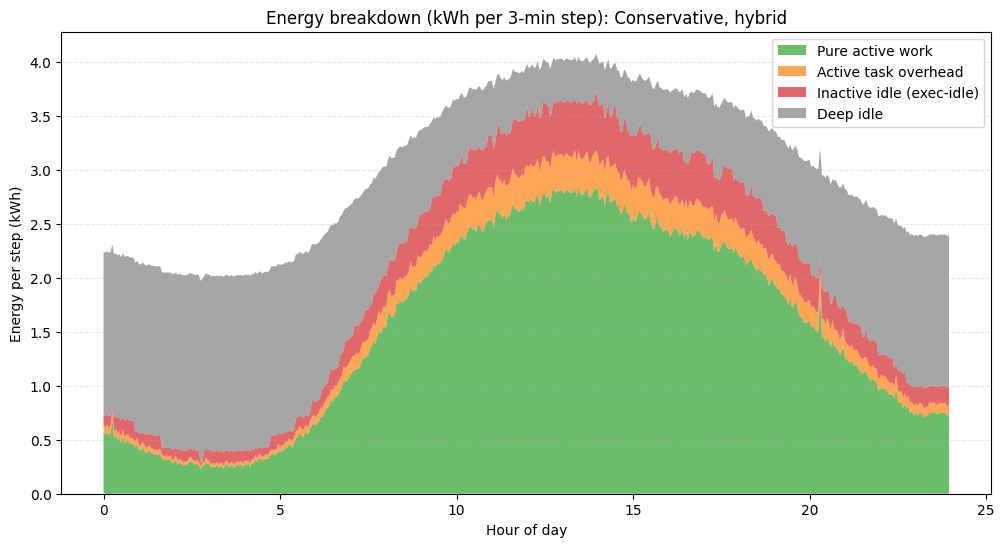

--- Daily energy summary: Conservative, hybrid ---
Total daily energy:      1451.60 kWh
  Pure active work:       737.19 kWh ( 50.8%)
  Active task overhead:    88.42 kWh (  6.1%)
  Inactive idle:          141.48 kWh (  9.7%)
  Deep idle:              484.51 kWh ( 33.4%)

--- Efficiency metrics ---
Workload efficiency     (work / active state):   89.3%
Provisioning efficiency (work / total energy):   50.8%

Ideal energy (no idle): 737.19 kWh
Total waste vs ideal:   714.41 kWh


In [5]:
# --- Block 4: Detailed Energy Analysis ---
import numpy as np
import matplotlib.pyplot as plt

# Use rho_state (clipped at 1.0) for the energy partition, since when
# rho_effective > 1 the cluster is in SLA violation and physically all
# ready GPUs are active.
rho_state = np.minimum(rho_effective, 1.0)

# Power per simulation step (Watts)
pure_active_power     = gpus_active * P_active_avg
active_overhead_power = c_ready * rho_state * EXEC_IDLE_FRAC * P_execution_idle
inactive_idle_power   = c_ready * (1 - rho_state) * P_execution_idle
deep_idle_power       = gpus_deep_idle * P_idle

# Convert to kWh per simulation step (multiply by step_hours, divide by 1000)
energy_pure_work       = (pure_active_power     * step_hours) / 1000
energy_active_overhead = (active_overhead_power * step_hours) / 1000
energy_inactive_idle   = (inactive_idle_power   * step_hours) / 1000
energy_deep_idle       = (deep_idle_power       * step_hours) / 1000

energy_total = (energy_pure_work + energy_active_overhead
                + energy_inactive_idle + energy_deep_idle)

# Ideal scenario: only pure work, no idle
energy_ideal = (pure_active_power * step_hours) / 1000

# Visualisation
plt.figure(figsize=(12, 6))
plt.stackplot(hours_96,
              energy_pure_work, energy_active_overhead,
              energy_inactive_idle, energy_deep_idle,
              labels=['Pure active work', 'Active task overhead',
                      'Inactive idle (exec-idle)', 'Deep idle'],
              colors=['#2ca02c', '#ff7f0e', '#d62728', '#7f7f7f'],
              alpha=0.7)
plt.title(f'Energy breakdown (kWh per {cluster.step_minutes:.0f}-min step): {strategy_mode}, {arrival_mode}')
plt.xlabel('Hour of day')
plt.ylabel('Energy per step (kWh)')
plt.legend(loc='upper right')
plt.grid(axis='y', linestyle='--', alpha=0.3)
fig.savefig(FIG_DIR / "energy_breakdown_by_state.png", dpi=300, bbox_inches="tight")
plt.show()
plt.close()

# Aggregate statistics
total_kwh    = np.sum(energy_total)
work_kwh     = np.sum(energy_pure_work)
overhead_kwh = np.sum(energy_active_overhead)
idle_kwh     = np.sum(energy_inactive_idle)
deep_kwh     = np.sum(energy_deep_idle)

print(f"--- Daily energy summary: {strategy_mode}, {arrival_mode} ---")
print(f"Total daily energy:      {total_kwh:7.2f} kWh")
print(f"  Pure active work:      {work_kwh:7.2f} kWh ({(work_kwh/total_kwh)*100:5.1f}%)")
print(f"  Active task overhead:  {overhead_kwh:7.2f} kWh ({(overhead_kwh/total_kwh)*100:5.1f}%)")
print(f"  Inactive idle:         {idle_kwh:7.2f} kWh ({(idle_kwh/total_kwh)*100:5.1f}%)")
print(f"  Deep idle:             {deep_kwh:7.2f} kWh ({(deep_kwh/total_kwh)*100:5.1f}%)")

# Two efficiency metrics, separated as discussed in Ch 5:
#   - Workload efficiency: how much of "active GPU time" is actually work
#   - Provisioning efficiency: how much of total energy is actually work
active_state_total = work_kwh + overhead_kwh
print(f"\n--- Efficiency metrics ---")
print(f"Workload efficiency     (work / active state):  "
      f"{(work_kwh/active_state_total)*100:5.1f}%")
print(f"Provisioning efficiency (work / total energy):  "
      f"{(work_kwh/total_kwh)*100:5.1f}%")

ideal_total_kwh = np.sum(energy_ideal)
print(f"\nIdeal energy (no idle): {ideal_total_kwh:.2f} kWh")
print(f"Total waste vs ideal:   {total_kwh - ideal_total_kwh:.2f} kWh")


In [6]:
# --- Block 5: Strategy x Arrival Process Comparison (20-seed aggregate) ---
# Always compares NHPP + Pareto bursts [M/M/c] against Gamma renewal [G/M/c]
# across N_SEEDS independent realisations, reporting mean ± std for each
# metric. Single-seed numbers (e.g. Block 1's burst plot) are one draw from
# this distribution; this block is the evidence behind any claim made about
# the comparison.
import numpy as np

from src.Simulation import build_lambda_15min

N_SEEDS = 20

def run_one(lambda_arr, c_active_arr):
    # Cold-start lag
    c_r = np.zeros(num_steps)
    c_r[0] = c_active_arr[0]
    for t in range(1, num_steps):
        c_r[t] = np.minimum(c_active_arr[t], c_active_arr[t-1])

    cap = c_r * mu
    rho_eff = np.where(cap > 0, lambda_arr / np.maximum(cap, 1e-9), 0.0)
    rho_s = np.minimum(rho_eff, 1.0)

    g_active     = c_r * rho_s * (1 - EXEC_IDLE_FRAC)
    e_pure       = (g_active * P_active_avg * step_hours) / 1000
    e_overhead   = (c_r * rho_s * EXEC_IDLE_FRAC * P_execution_idle * step_hours) / 1000
    e_inactive   = (c_r * (1 - rho_s) * P_execution_idle * step_hours) / 1000
    e_deep       = ((total_gpus - c_r) * P_idle * step_hours) / 1000
    e_total      = e_pure + e_overhead + e_inactive + e_deep

    return {
        'total': float(np.sum(e_total)),
        'pure':  float(np.sum(e_pure)),
        'oh':    float(np.sum(e_overhead)),
        'inact': float(np.sum(e_inactive)),
        'deep':  float(np.sum(e_deep)),
        'mean_rho': float(np.mean(rho_eff)),
        'max_rho':  float(np.max(rho_eff)),
        'sla_viol': int(np.sum(rho_eff > 1.0)),
    }

def provisioning(lambda_arr):
    return {
        'Static':       np.full(num_steps, total_gpus),
        'Conservative': np.minimum(scale_in_pods(lambda_arr / (cluster.target_rho_conservative * mu)), total_gpus),
        'Moderate':     np.minimum(scale_in_pods(lambda_arr / (cluster.target_rho_moderate     * mu)), total_gpus),
        'Tight':        np.minimum(scale_in_pods(lambda_arr / (cluster.target_rho_tight        * mu)), total_gpus),
        'Aggressive':   np.minimum(scale_in_pods(lambda_arr / (cluster.target_rho_aggressive   * mu)), total_gpus),
    }

pareto_label = 'NHPP + Pareto [M/M/c]'
gamma_label  = f'Gamma (shape={arrival_params.gamma_renewal_shape}) [G/M/c]'

STRATS = ['Static', 'Conservative', 'Moderate', 'Tight', 'Aggressive']
METRICS = [
    ('total',    'Total kWh'),
    ('pure',     'Pure work'),
    ('oh',       'Overhead'),
    ('inact',    'Inactive idle'),
    ('deep',     'Deep idle'),
    ('mean_rho', 'Mean rho'),
    ('max_rho',  'Max rho'),
    ('sla_viol', f'SLA viol /{num_steps}'),
]

# samples[am][strategy][metric] -> list of N_SEEDS values
samples = {am: {s: {m: [] for m, _ in METRICS} for s in STRATS}
           for am in ('pareto', 'gamma')}

for seed in range(N_SEEDS):
    lambda_pareto = build_lambda_15min(
        arrival_mode='hybrid',
        burst_params=BurstParams(distribution='pareto'),
        arrival_params=arrival_params,
        lambda_hourly=lambda_hourly, lambda_peak=lambda_peak,
        lambda_15min_nhpp=lambda_15min_nhpp,
        T=T_day, num_steps=num_steps, step_hours=step_hours,
        seed=seed,
    )
    lambda_gamma = build_lambda_15min(
        arrival_mode='gamma_renewal',
        burst_params=BurstParams(distribution='pareto'),
        arrival_params=arrival_params,
        lambda_hourly=lambda_hourly, lambda_peak=lambda_peak,
        lambda_15min_nhpp=lambda_15min_nhpp,
        T=T_day, num_steps=num_steps, step_hours=step_hours,
        seed=seed,
    )
    for am, l_arr in [('pareto', lambda_pareto), ('gamma', lambda_gamma)]:
        prov = provisioning(l_arr)
        for s in STRATS:
            r = run_one(l_arr, prov[s])
            for m, _ in METRICS:
                samples[am][s][m].append(r[m])

def fmt(vals, metric):
    m = float(np.mean(vals)); sd = float(np.std(vals, ddof=1))
    if metric in ('mean_rho', 'max_rho'):
        return f"{m:6.2f} ±{sd:5.2f}"
    if metric == 'sla_viol':
        return f"{m:6.1f} ±{sd:5.1f}"
    return f"{m:6.1f} ±{sd:5.1f}"

col_w   = 15
label_w = 18

print(f"Aggregate of {N_SEEDS} seeds (mean ± std)\n")
print(f"{'':<{label_w}}"
      f"{pareto_label:^{col_w*len(STRATS)}} | {gamma_label:^{col_w*len(STRATS)}}")
short = {'Static':'Static','Conservative':'Cons.','Moderate':'Mod.',
         'Tight':'Tight','Aggressive':'Aggr.'}
header = ''.join(f"{short[s]:>{col_w}}" for s in STRATS)
print(f"{'':<{label_w}}{header} | {header}")
print('-' * (label_w + col_w*len(STRATS)*2 + 3))

for metric, label in METRICS:
    row = f"{label:<{label_w}}"
    for am in ['pareto', 'gamma']:
        for s in STRATS:
            row += f"{fmt(samples[am][s][metric], metric):>{col_w}}"
        if am == 'pareto':
            row += " |"
    print(row)


Aggregate of 20 seeds (mean ± std)

                                             NHPP + Pareto [M/M/c]                            |                          Gamma (shape=0.5) [G/M/c]                         
                           Static          Cons.           Mod.          Tight          Aggr. |          Static          Cons.           Mod.          Tight          Aggr.
---------------------------------------------------------------------------------------------------------------------------------------------------------------------------
Total kWh           1728.4 ±  0.3  1451.6 ±  0.5  1434.5 ±  0.4  1423.9 ±  0.4  1414.3 ±  0.5 |  1726.5 ±  0.4  1448.2 ±  0.6  1431.2 ±  0.7  1420.4 ±  0.8  1411.0 ±  0.8
Pure work            737.1 ±  0.6   737.1 ±  0.6   737.1 ±  0.6   737.1 ±  0.6   736.9 ±  0.6 |   733.3 ±  0.8   733.3 ±  0.8   733.3 ±  0.8   733.3 ±  0.8   733.2 ±  0.8
Overhead              88.4 ±  0.1    88.4 ±  0.1    88.4 ±  0.1    88.4 ±  0.1    88.4 ±  0.1 |    88.0 ± 

## Headroom Sweep — SLA Violations vs Provisioning Overhead

Conservative (78%) and Aggressive (95%) are two fixed points on the
same dial: the target effective utilisation ρ*, with headroom equal
to ``1 - ρ*``. This block sweeps ρ* from 0.75 (25% overhead) to
1.00 (0% overhead) and counts SLA violations — simulation steps where
the effective utilisation exceeded 1.0 — against the workload pinned
by Block 0.

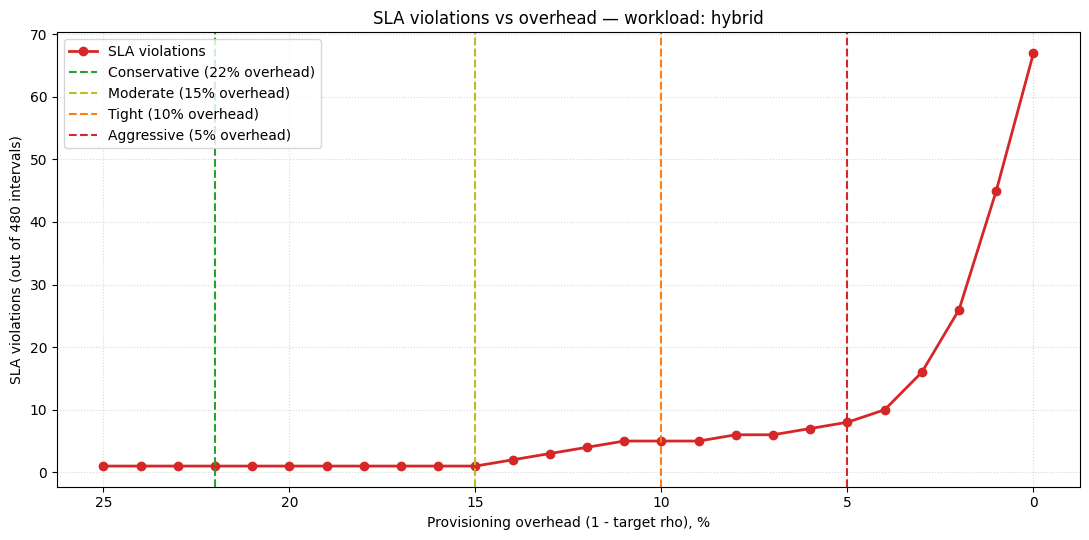

  Overhead %    Target rho    SLA viol
--------------------------------------
        25.0         0.750           1
        24.0         0.760           1
        23.0         0.770           1
        22.0         0.780           1
        21.0         0.790           1
        20.0         0.800           1
        19.0         0.810           1
        18.0         0.820           1
        17.0         0.830           1
        16.0         0.840           1
        15.0         0.850           1
        14.0         0.860           2
        13.0         0.870           3
        12.0         0.880           4
        11.0         0.890           5
        10.0         0.900           5
         9.0         0.910           5
         8.0         0.920           6
         7.0         0.930           6
         6.0         0.940           7
         5.0         0.950           8
         4.0         0.960          10
         3.0         0.970          16
         2.0         0.98

In [7]:
# --- Block 6: Headroom Sweep — SLA Violations vs Overhead ---
import numpy as np
import matplotlib.pyplot as plt

from src.Simulation import (
    apply_cold_start_lag,
    build_lambda_15min,
    utilisation_arrays,
)

# Pin the workload to whatever Block 0 / Block 1 selected.
l_arr = build_lambda_15min(
    arrival_mode=arrival_mode, burst_params=burst_params,
    arrival_params=arrival_params,
    lambda_hourly=lambda_hourly, lambda_peak=lambda_peak,
    lambda_15min_nhpp=lambda_15min_nhpp,
    T=T_day, num_steps=num_steps, step_hours=step_hours,
)

# Sweep target rho from 0.75 (25% overhead) up to 1.00 (0% overhead).
target_rhos = np.linspace(0.75, 1.00, 26)
overhead_pct = (1.0 - target_rhos) * 100.0
violations = np.zeros_like(target_rhos, dtype=int)

for i, rho_star in enumerate(target_rhos):
    c_target = np.minimum(scale_in_pods(l_arr / (rho_star * mu)), total_gpus)
    c_ready_i = apply_cold_start_lag(c_target)
    util_i = utilisation_arrays(l_arr, c_target, c_ready_i, mu, total_gpus)
    violations[i] = int(np.sum(util_i["rho_effective"] > 1.0))

# Strategy reference points (decreasing headroom)
refs = [
    ("Conservative", cluster.target_rho_conservative, "tab:green"),
    ("Moderate",     cluster.target_rho_moderate,     "tab:olive"),
    ("Tight",        cluster.target_rho_tight,        "tab:orange"),
    ("Aggressive",   cluster.target_rho_aggressive,   "tab:red"),
]

fig, ax = plt.subplots(figsize=(11, 5.5))
ax.plot(overhead_pct, violations, marker="o", linewidth=2,
        color="tab:red", label="SLA violations")
for name, rho_star, color in refs:
    pct = (1.0 - rho_star) * 100.0
    ax.axvline(pct, color=color, linestyle="--", linewidth=1.5,
               label=f"{name} ({pct:.0f}% overhead)")
ax.invert_xaxis()  # 25% → 0% left-to-right
ax.set_xlabel("Provisioning overhead (1 - target rho), %")
ax.set_ylabel(f"SLA violations (out of {num_steps} intervals)")
ax.set_title(f"SLA violations vs overhead — workload: {arrival_mode}")
ax.grid(True, linestyle=":", alpha=0.5)
ax.legend(loc="upper left")
plt.tight_layout()
fig.savefig(FIG_DIR / "headroom_sweep_violations.png",
            dpi=300, bbox_inches="tight")
plt.show()
plt.close()

print(f"{'Overhead %':>12s}{'Target rho':>14s}{'SLA viol':>12s}")
print("-" * 38)
for op, tr, v in zip(overhead_pct, target_rhos, violations):
    print(f"{op:12.1f}{tr:14.3f}{v:12d}")


## Block 7 — Compare Provisioning Strategies

For the currently selected workload (`arrival_mode` + `burst_distribution`
from Block 0), this block runs the simulation under every strategy in
`STRATEGIES` (Static, Conservative, Aggressive) and produces three saved
comparison figures:

- `comparison_summary.png` — total kWh, work fraction, max ρ, SLA violations
- `comparison_utilisation_grid.png` — side-by-side ρ(t) plots per strategy
- `comparison_energy_breakdown.png` — stacked-bar energy components per strategy

To compare a different workload, change `arrival_mode` / `burst_distribution`
in Block 0 and re-run.


Workload: Pareto bursts [M/M/c + pareto burst overlay]

Strategy            TotalkWh   Work%  MaxRho   SLA/480
------------------------------------------------------
Static                1728.5    42.7    0.63         0
Conservative          1452.0    50.8    1.24         1
Moderate              1434.8    51.4    1.24         1
Tight                 1423.4    51.8    1.66         5
Aggressive            1413.7    52.1    1.66         8


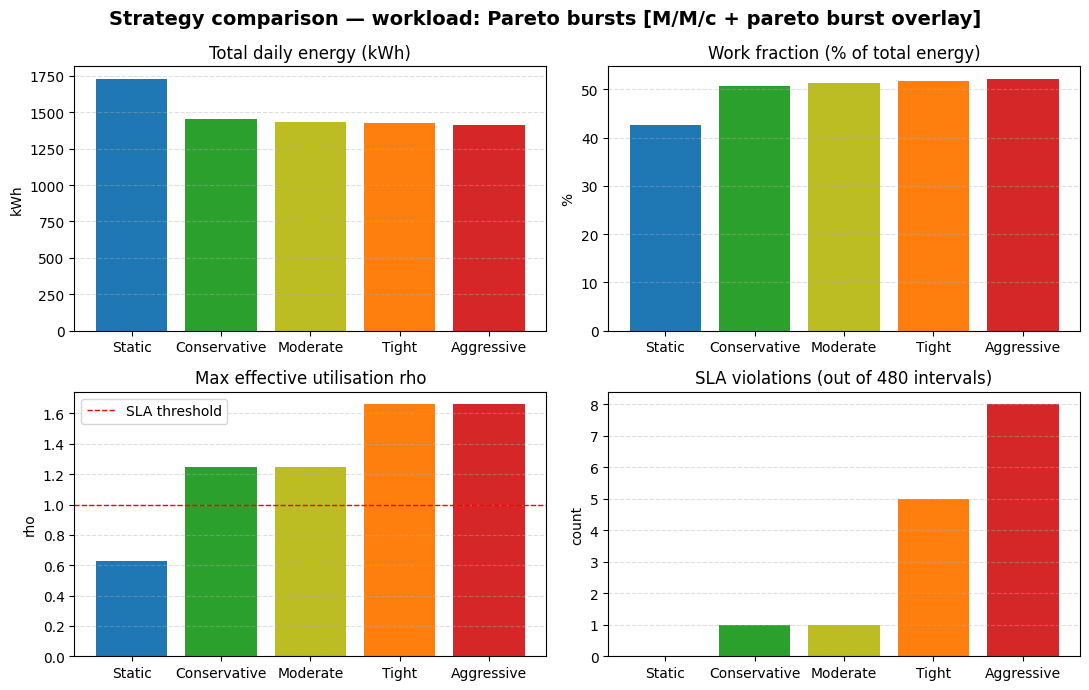

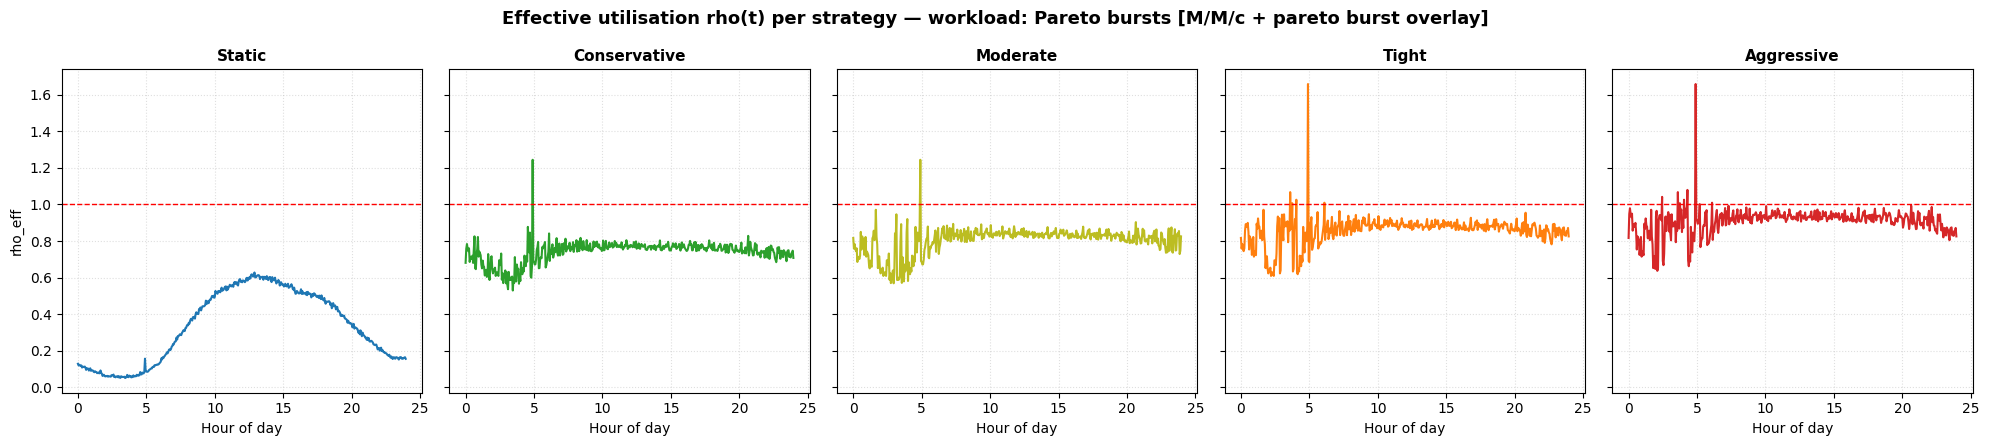

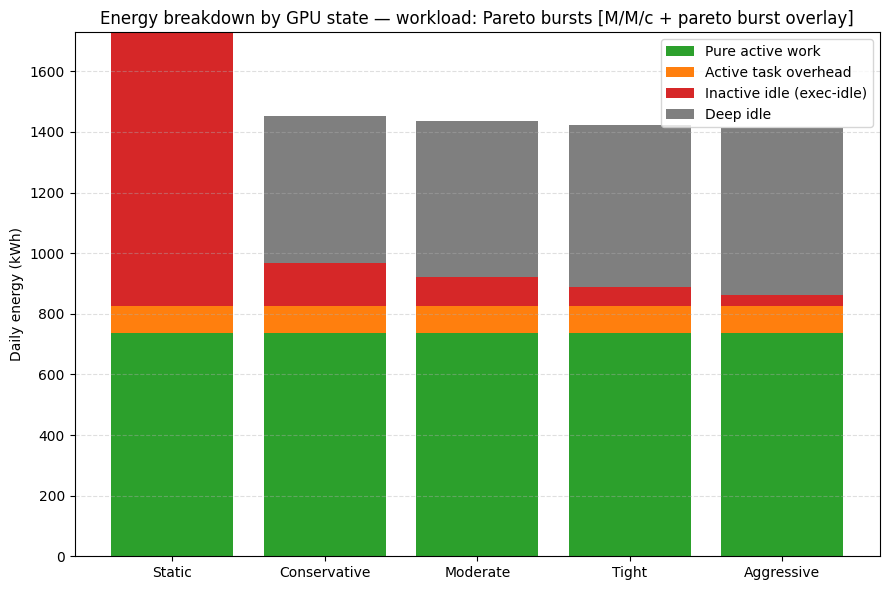


Saved 3 comparison figures to C:\Users\edvin\Documents\ITK\Project Web\Modeling-of-the-Energy-Consumption-of-AI-Inference-Workloads\figures


In [8]:
# --- Block 7: Compare Provisioning Strategies for the Selected Workload ---
import numpy as np
import matplotlib.pyplot as plt

from src.Simulation import (
    apply_cold_start_lag,
    build_lambda_15min,
    energy_arrays,
    gpu_state_arrays,
    provisioning_arrays,
    utilisation_arrays,
)

# --- Pin the workload to whatever Block 0 / Block 1 selected ---
if arrival_mode == 'nhpp_only':
    workload_label = 'NHPP only [M/M/c]'
elif arrival_mode == 'hybrid':
    workload_label = (
        f"{burst_distribution.capitalize()} bursts "
        f"[M/M/c + {burst_distribution} burst overlay]"
    )
elif arrival_mode == 'gamma_renewal':
    workload_label = (
        f"Gamma renewal (shape={arrival_params.gamma_renewal_shape}, "
        f"CV~={1/np.sqrt(arrival_params.gamma_renewal_shape):.2f}) [G/M/c]"
    )

l_arr = build_lambda_15min(
    arrival_mode=arrival_mode, burst_params=burst_params,
    arrival_params=arrival_params,
    lambda_hourly=lambda_hourly, lambda_peak=lambda_peak,
    lambda_15min_nhpp=lambda_15min_nhpp,
    T=T_day, num_steps=num_steps, step_hours=step_hours,
)
prov = provisioning_arrays(l_arr, mu=mu, total_gpus=total_gpus, pod_size=pod_size)

# --- Run every strategy against the pinned workload ---
scenarios: list[dict] = []
for s in STRATEGIES:
    c_active_arr = prov[s]
    c_ready = apply_cold_start_lag(c_active_arr)
    util = utilisation_arrays(l_arr, c_active_arr, c_ready, mu, total_gpus)
    states = gpu_state_arrays(c_ready, util['rho_effective'], total_gpus,
                               power.execution_idle_fraction)
    energy = energy_arrays(c_ready, util['rho_effective'],
                            states['gpus_active'], states['gpus_deep_idle'], power,
                            step_hours=step_hours)
    scenarios.append({
        'strategy': s,
        'lambda': l_arr, 'c_active': c_active_arr, 'c_ready': c_ready,
        'util': util, 'states': states, 'energy': energy,
    })

# --- Print summary table ---
print(f"Workload: {workload_label}\n")
print(f"{'Strategy':16s}{'TotalkWh':>12s}{'Work%':>8s}{'MaxRho':>8s}{f'SLA/{num_steps}':>10s}")
print('-' * 54)
for sc in scenarios:
    e, u = sc['energy'], sc['util']
    work_pct = 100 * e['work_kwh'] / e['total_kwh']
    sla = int(np.sum(u['rho_effective'] > 1.0))
    print(f"{sc['strategy']:16s}{e['total_kwh']:12.1f}{work_pct:8.1f}"
          f"{u['rho_effective'].max():8.2f}{sla:10d}")

labels = [sc['strategy'] for sc in scenarios]
strategy_colors = {'Static':       'tab:blue',
                    'Conservative': 'tab:green',
                    'Moderate':     'tab:olive',
                    'Tight':        'tab:orange',
                    'Aggressive':   'tab:red'}
colors = [strategy_colors[s] for s in labels]

# --- Figure 1: 2x2 summary bar charts ---
fig, axes = plt.subplots(2, 2, figsize=(11, 7))
ax = axes[0, 0]
ax.bar(labels, [sc['energy']['total_kwh'] for sc in scenarios], color=colors)
ax.set_title('Total daily energy (kWh)'); ax.set_ylabel('kWh')
ax.grid(axis='y', linestyle='--', alpha=0.4)

ax = axes[0, 1]
ax.bar(labels, [100 * sc['energy']['work_kwh'] / sc['energy']['total_kwh']
                 for sc in scenarios], color=colors)
ax.set_title('Work fraction (% of total energy)'); ax.set_ylabel('%')
ax.grid(axis='y', linestyle='--', alpha=0.4)

ax = axes[1, 0]
ax.bar(labels, [float(sc['util']['rho_effective'].max()) for sc in scenarios],
        color=colors)
ax.axhline(1.0, color='red', linestyle='--', linewidth=1, label='SLA threshold')
ax.set_title('Max effective utilisation rho'); ax.set_ylabel('rho')
ax.grid(axis='y', linestyle='--', alpha=0.4)
ax.legend(loc='upper left')

ax = axes[1, 1]
ax.bar(labels, [int(np.sum(sc['util']['rho_effective'] > 1.0))
                 for sc in scenarios], color=colors)
ax.set_title(f'SLA violations (out of {num_steps} intervals)'); ax.set_ylabel('count')
ax.grid(axis='y', linestyle='--', alpha=0.4)

plt.suptitle(f'Strategy comparison — workload: {workload_label}',
             fontsize=14, fontweight='bold')
plt.tight_layout()
fig.savefig(FIG_DIR / 'comparison_summary.png', dpi=300, bbox_inches='tight')
plt.show(); plt.close()

# --- Figure 2: side-by-side rho(t) plots, one per strategy ---
fig, axes = plt.subplots(1, len(STRATEGIES), figsize=(20, 4.5),
                          sharex=True, sharey=True)
for c, sc in enumerate(scenarios):
    ax = axes[c]
    ax.plot(hours_96, sc['util']['rho_effective'],
            color=strategy_colors[sc['strategy']], linewidth=1.5)
    ax.axhline(1.0, color='red', linestyle='--', linewidth=1)
    ax.set_title(sc['strategy'], fontsize=11, fontweight='bold')
    ax.set_xlabel('Hour of day')
    ax.grid(True, linestyle=':', alpha=0.4)
    if c == 0:
        ax.set_ylabel('rho_eff')
plt.suptitle(f'Effective utilisation rho(t) per strategy — workload: {workload_label}',
             fontsize=13, fontweight='bold')
plt.tight_layout()
fig.savefig(FIG_DIR / 'comparison_utilisation_grid.png',
             dpi=300, bbox_inches='tight')
plt.show(); plt.close()

# --- Figure 3: stacked bar of energy components per strategy ---
work_vals     = np.array([sc['energy']['work_kwh']     for sc in scenarios])
overhead_vals = np.array([sc['energy']['overhead_kwh'] for sc in scenarios])
inactive_vals = np.array([sc['energy']['idle_kwh']     for sc in scenarios])
deep_vals     = np.array([sc['energy']['deep_kwh']     for sc in scenarios])
x = np.arange(len(labels))

fig, ax = plt.subplots(figsize=(9, 6))
ax.bar(x, work_vals,     label='Pure active work',          color='#2ca02c')
ax.bar(x, overhead_vals, bottom=work_vals,
        label='Active task overhead', color='#ff7f0e')
ax.bar(x, inactive_vals, bottom=work_vals + overhead_vals,
        label='Inactive idle (exec-idle)', color='#d62728')
ax.bar(x, deep_vals,     bottom=work_vals + overhead_vals + inactive_vals,
        label='Deep idle', color='#7f7f7f')
ax.set_xticks(x); ax.set_xticklabels(labels)
ax.set_ylabel('Daily energy (kWh)')
ax.set_title(f'Energy breakdown by GPU state — workload: {workload_label}')
ax.legend(loc='upper right'); ax.grid(axis='y', linestyle='--', alpha=0.4)
plt.tight_layout()
fig.savefig(FIG_DIR / 'comparison_energy_breakdown.png',
             dpi=300, bbox_inches='tight')
plt.show(); plt.close()

print(f"\nSaved 3 comparison figures to {FIG_DIR.resolve()}")
